# KLASIFIKASI GENRE GAME BERDASARKAN SINOPSIS
---
**Author:** *Muhammad Wira Widhana [24.55.2717]*

## Library & Load Dataset

library 

In [1]:
import pandas as pd
import numpy as np

import re
import langdetect
from langdetect import detect

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC

from sklearn.metrics import classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# pertama kali saja:
"""
nltk.download('punkt')
nltk.download('stopwords')
"""

"\nnltk.download('punkt')\nnltk.download('stopwords')\n"

## Load dan Memeriksa Data (Data Loading & EDA)

Load Data

In [3]:
df = pd.read_csv('games_fixed.csv')
df.head()

,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,About the game,...,Median playtime two weeks,Average playtime forever,Median playtime forever,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
0,10,Counter-Strike,"Nov 1, 2000",10000000 - 20000000,7323,0,1.99,80,0,Play the world's number 1 online action game. ...,...,99,10735,185,['Valve'],['Valve'],"['Multi-player', 'PvP', 'Online PvP', 'Shared/...",['Action'],"{'Action': 5504, 'FPS': 4929, 'Multiplayer': 3...",['https://shared.akamai.steamstatic.com/store_...,[]
1,100,Counter-Strike: Condition Zero,"Mar 1, 2004",10000000 - 20000000,83,0,1.99,80,0,"With its extensive Tour of Duty campaign, a ne...",...,1,431,32,['Valve'],['Valve'],"['Single-player', 'Multi-player', 'Color Alter...",['Action'],"{'Action': 1339, 'FPS': 979, 'Shooter': 723, '...",['https://shared.akamai.steamstatic.com/store_...,[]
2,1000000,ASCENXION,"May 14, 2021",0 - 20000,0,0,1.49,0,1,ASCENXION is a 2D shoot 'em up game where you ...,...,0,0,0,['IndigoBlue Game Studio'],['PsychoFlux Entertainment'],"['Single-player', 'Steam Achievements', 'Parti...","['Action', 'Adventure', 'Indie']","{""Shoot 'Em Up"": 186, 'Metroidvania': 181, 'Bu...",['https://shared.akamai.steamstatic.com/store_...,[]
3,1000010,Crown Trick,"Oct 16, 2020",500000 - 1000000,14,0,4.99,0,2,Crown Trick is a beautifully animated rogue-li...,...,0,702,397,['NEXT Studios'],"['Team17', 'NEXT Studios']","['Single-player', 'Steam Achievements', 'Steam...","['Adventure', 'Indie', 'RPG', 'Strategy']","{'Rogue-like': 275, 'Turn-Based Combat': 258, ...",['https://shared.akamai.steamstatic.com/store_...,[]
4,1000030,"Cook, Serve, Delicious! 3?!","Oct 14, 2020",100000 - 200000,27,0,4.99,75,1,Hit the road in this massive sequel to the mil...,...,0,281,118,['Vertigo Gaming Inc.'],['Vertigo Gaming Inc.'],"['Single-player', 'Multi-player', 'Co-op', 'Sh...","['Action', 'Indie', 'Simulation', 'Strategy']","{'Typing': 227, 'Management': 219, 'Difficult'...",['https://shared.akamai.steamstatic.com/store_...,[]


Pilih kolom yang relevan

In [4]:
# Seleksi kolom yang relevan

df = df[["Name", "About the game", "Genres", "Supported languages"]]

# Ganti nama kolom agar konsisten
df = df.rename(columns={
    "About the game": "synopsis",
    "Genres": "genres",
    "Supported languages": "languages"
})

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122611 entries, 0 to 122610
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Name       122610 non-null  object
 1   synopsis   114163 non-null  object
 2   genres     122611 non-null  object
 3   languages  122611 non-null  object
dtypes: object(4)
memory usage: 3.7+ MB


,Name,synopsis,genres,languages
0,Counter-Strike,Play the world's number 1 online action game. ...,['Action'],"['English', 'French', 'German', 'Italian', 'Sp..."
1,Counter-Strike: Condition Zero,"With its extensive Tour of Duty campaign, a ne...",['Action'],"['English', 'French', 'German', 'Italian', 'Sp..."
2,ASCENXION,ASCENXION is a 2D shoot 'em up game where you ...,"['Action', 'Adventure', 'Indie']","['Korean', 'English', 'Simplified Chinese']"
3,Crown Trick,Crown Trick is a beautifully animated rogue-li...,"['Adventure', 'Indie', 'RPG', 'Strategy']","['Simplified Chinese', 'English', 'Japanese', ..."
4,"Cook, Serve, Delicious! 3?!",Hit the road in this massive sequel to the mil...,"['Action', 'Indie', 'Simulation', 'Strategy']",['English']


EDA Singkat

In [12]:
# Cek jumlah baris dan missing values
print("Jumlah data:", len(df))
print("\nMissing values per kolom:")
df.isna().sum()

Jumlah data: 122611

Missing values per kolom:


Name            1
synopsis     8448
genres          0
languages       0
dtype: int64

In [13]:
# Cek distribusi genre
print("\nDistribusi awal genre:")
df['genres'].value_counts().head(20)


Distribusi awal genre:


genres
[]                                            8413
['Casual', 'Indie']                           6700
['Action', 'Indie']                           5679
['Action', 'Adventure', 'Indie']              5159
['Adventure', 'Indie']                        4311
['Adventure', 'Casual', 'Indie']              3610
['Action', 'Casual', 'Indie']                 3422
['Casual']                                    3351
['Indie']                                     3075
['Action']                                    2954
['Casual', 'Indie', 'Strategy']               2250
['Casual', 'Indie', 'Simulation']             2185
['Adventure']                                 2125
['Action', 'Adventure', 'Casual', 'Indie']    2057
['Action', 'Adventure']                       1653
['Adventure', 'Casual']                       1589
['Adventure', 'Indie', 'RPG']                 1539
['Action', 'Adventure', 'Indie', 'RPG']       1534
['Strategy']                                  1359
['Indie', 'Strategy']   

In [14]:
# Hitung panjang sinopsis (jumlah kata)
df['synopsis_raw'] = df['synopsis'].fillna('')

df['word_count_raw'] = df['synopsis_raw'].apply(lambda x: len(str(x).split()))
df['word_count_raw'].describe()

count    122611.000000
mean        199.491579
std         169.191664
min           0.000000
25%         100.000000
50%         167.000000
75%         260.000000
max       11530.000000
Name: word_count_raw, dtype: float64

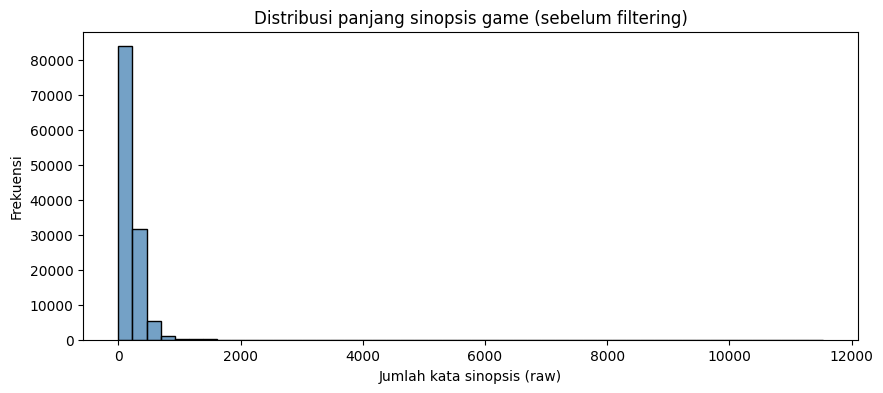

In [15]:
# Visualisasi distribusi panjang sinopsis (sebelum filtering)
plt.figure(figsize=(10,4))
sns.histplot(df['word_count_raw'], bins=50, kde=False, color='steelblue')
plt.xlabel('Jumlah kata sinopsis (raw)')
plt.ylabel('Frekuensi')
plt.title('Distribusi panjang sinopsis game (sebelum filtering)')
plt.show()

## Filter Bahasa Inggris & Penghapusan Sinopsis Terlalu Pendek

hanya sinopsis bahasa Inggris yang digunakan dan sinopsis terlalu pendek dihapus berdasarkan threshold dari distribusi panjang teks.

In [17]:
# 3.1. Fungsi deteksi bahasa sederhana dengan langdetect

def detect_language_safe(text):
    text = str(text)
    text_strip = text.strip()
    if len(text_strip) < 20:  # terlalu pendek, sering gagal deteksi
        return 'unknown'
    try:
        return detect(text_strip)
    except:
        return 'error'

# Deteksi bahasa pada sinopsis
df['lang'] = df['synopsis_raw'].apply(detect_language_safe)

df['lang'].value_counts()

lang
en         112068
unknown      8469
zh-cn        1252
ja            409
ko            153
ru             40
zh-tw          37
fr             31
pt             28
es             27
de             26
it              8
pl              8
tr              7
ar              7
ro              5
th              4
error           4
ca              3
no              3
uk              3
cs              3
vi              2
sk              2
he              2
et              2
sv              1
el              1
nl              1
da              1
id              1
bg              1
sw              1
hu              1
Name: count, dtype: int64

In [18]:
# Filter hanya sinopsis berbahasa Inggris ('en')

df_en = df[df['lang'] == 'en'].copy()
print("Jumlah data sebelum filter bahasa:", len(df))
print("Jumlah data setelah filter bahasa Inggris:", len(df_en))

Jumlah data sebelum filter bahasa: 122611
Jumlah data setelah filter bahasa Inggris: 112068


## PRE-Prosessing


## Modeling & Training

## Evaluasi Model


## Implementasi